# 📊 Análise Exploratória de Dados (EDA) - Performance Comercial & Financeira

**Objetivo do Projeto:** Avaliar a eficiência dos canais de vendas, impacto da política de descontos, comportamento de inadimplência/atrasos e desempenho da equipe comercial a partir do banco de dados relacional `vendas.db`.

**Principais Pergunta de Negócio:**
1. Qual é a saúde do faturamento bruto vs. líquido e o impacto real dos descontos?
2. Quais canais e formas de pagamento apresentam maior taxa de atraso no recebimento?
3. Quais produtos representam 80% do faturamento da empresa (Curva ABC / Princípio de Pareto)?
4. Qual é o custo relativo de comissão em relação ao faturamento gerado por vendedor?

Setup, Conexão com SQLite e Bibliotecas

In [ ]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Configuração de visualização do Pandas e Plotly
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Conexão com o banco SQLite gerado pelo etl.py
DB_PATH = 'vendas.db'
conn = sqlite3.connect(DB_PATH)

print("✅ Conexão com o SQLite estabelecida com sucesso!")

✅ Conexão com o SQLite estabelecida com sucesso!


## 1. Visão Macro: Faturamento Bruto, Líquido e Elasticidade do Desconto
Nesta seção, extraímos os indicadores globais diretamente do banco de dados via SQL e analisamos a margem consumida por concessão de descontos.

In [ ]:
# Verificar quais tabelas existem no banco
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tabelas encontradas:", cursor.fetchall())

Tabelas encontradas: [('vendas',), ('tb_vendas',)]


Consulta SQL e KPIs Executivos

In [ ]:
query_kpis = """
SELECT
    COUNT(DISTINCT id) AS total_pedidos,
    SUM(valor_bruto) AS faturamento_bruto,
    SUM(valor_desconto) AS total_descontos,
    SUM(valor_venda) AS faturamento_liquido,
    AVG(valor_venda) AS ticket_medio,
    (SUM(valor_desconto) / SUM(valor_bruto)) * 100 AS pct_desconto_medio
FROM tb_vendas;
"""

df_kpis = pd.read_sql_query(query_kpis, conn)

print("=== KPIs EXECUTIVOS DE VENDAS ===")
for col in df_kpis.columns:
    if "pct" in col:
        print(f"{col.upper().replace('_', ' ')}: {df_kpis[col].iloc[0]:.2f}%")
    elif "pedidos" in col:
        print(f"{col.upper().replace('_', ' ')}: {df_kpis[col].iloc[0]:,}")
    else:
        print(f"{col.upper().replace('_', ' ')}: R$ {df_kpis[col].iloc[0]:,.2f}")

=== KPIs EXECUTIVOS DE VENDAS ===
TOTAL PEDIDOS: 1,013
FATURAMENTO BRUTO: R$ 3,184,771.00
TOTAL DESCONTOS: R$ 236,223.67
FATURAMENTO LIQUIDO: R$ 2,948,547.33
TICKET MEDIO: R$ 2,910.71
PCT DESCONTO MEDIO: 7.42%


Gráfico de Faturamento vs Desconto por Canal de Venda

In [ ]:
query_canais = """
SELECT
    canal_venda,
    SUM(valor_bruto) AS faturamento_bruto,
    SUM(valor_desconto) AS total_desconto,
    SUM(valor_venda) AS faturamento_liquido,
    AVG(pct_desconto) AS media_pct_desconto
FROM tb_vendas
GROUP BY canal_venda
ORDER BY faturamento_liquido DESC;
"""

df_canais = pd.read_sql_query(query_canais, conn)

fig = px.bar(
    df_canais,
    x='canal_venda',
    y=['faturamento_liquido', 'total_desconto'],
    title='Faturamento Líquido vs. Descontos Concedidos por Canal de Venda',
    labels={
        'value': 'Valor em R$',
        'canal_venda': 'Canal de Venda',
        'variable': 'Métrica',
    },
    barmode='group',
    text_auto='.2s',
)
fig.update_layout(template='plotly_white')
fig.show()

## 2. Ciclo de Pagamento e Inadimplência/Atrasos
Calculamos os dias de diferença entre a `data_pagamento` e o `vencimento` usando funções de data nativas do SQLite (`julianday`).

Cálculo do Prazo de Pagamento e Dias de Atraso via SQL
Python

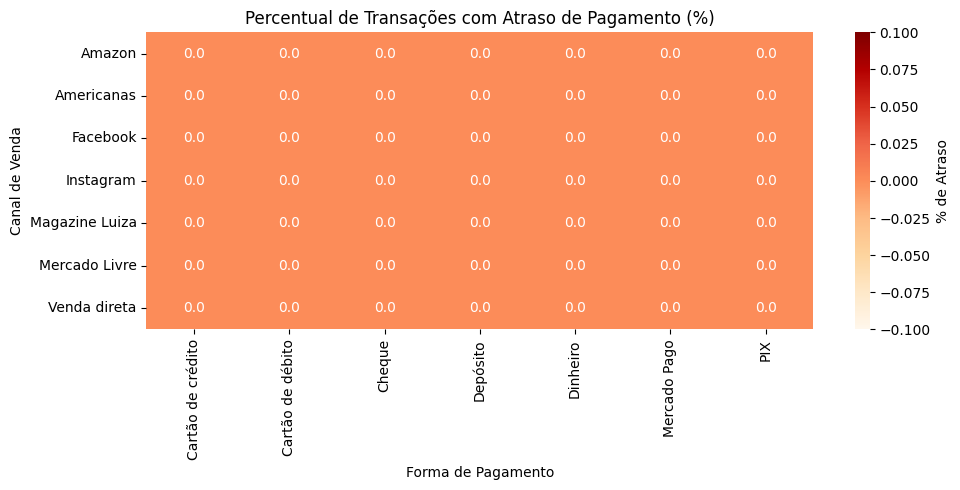

In [ ]:
# Query para calcular transações com atraso (considerando julianday do SQLite)
query_atrasos = """
SELECT
    canal_venda,
    forma_pagamento,
    COUNT(id) AS total_transacoes,
    SUM(
        CASE
            WHEN CAST(julianday(data_pagamento) - julianday(vencimento) AS INT) > 0 THEN 1
            ELSE 0
        END
    ) AS qtd_atrasos
FROM tb_vendas
WHERE data_pagamento IS NOT NULL
  AND data_pagamento != ''
  AND vencimento IS NOT NULL
  AND vencimento != ''
GROUP BY canal_venda, forma_pagamento
HAVING total_transacoes > 5;
"""

df_atrasos = pd.read_sql_query(query_atrasos, conn)

# Cálculo da taxa de atraso (%)
df_atrasos['pct_transacoes_com_atraso'] = (
    df_atrasos['qtd_atrasos'] / df_atrasos['total_transacoes']
) * 100

# Construção da Matriz de Calor (Heatmap)
plt.figure(figsize=(10, 5))
pivot_atraso = df_atrasos.pivot(
    index='canal_venda',
    columns='forma_pagamento',
    values='pct_transacoes_com_atraso'
).fillna(0)

sns.heatmap(pivot_atraso, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': '% de Atraso'})
plt.title('Percentual de Transações com Atraso de Pagamento (%)')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Canal de Venda')
plt.tight_layout()
plt.show()

In [ ]:
# Diagnóstico de datas e atrasos
query_teste = """
SELECT
    data,
    vencimento,
    data_pagamento,
    CAST(julianday(data_pagamento) - julianday(vencimento) AS INT) AS dias_diferenca
FROM tb_vendas
WHERE data_pagamento IS NOT NULL AND data_pagamento != ''
LIMIT 10;
"""
df_teste = pd.read_sql_query(query_teste, conn)
display(df_teste)

,data,vencimento,data_pagamento,dias_diferenca
0,2026-01-01,2026-01-12,2026-01-12,0
1,2026-01-01,2026-01-03,2026-01-03,0
2,2026-01-01,2026-01-24,2026-01-24,0
3,2026-01-04,2026-01-04,2026-01-04,0
4,2026-01-05,2026-01-12,2026-01-12,0
5,2026-01-06,2026-01-27,2026-01-27,0
6,2026-01-06,2026-02-04,2026-02-04,0
7,2026-01-06,2026-01-31,2026-01-31,0
8,2026-01-06,2026-01-25,2026-01-25,0
9,2026-01-07,2026-01-12,2026-01-12,0


## 3. Curva ABC de Produtos (Pareto)
Identificação dos produtos que concentram a maior proporção do faturamento acumulado.

Curva ABC com Gráfico de Pareto

In [ ]:
query_produtos = """
SELECT
    produto,
    SUM(valor_venda) AS faturamento_total
FROM tb_vendas
GROUP BY produto
ORDER BY faturamento_total DESC;
"""

df_abc = pd.read_sql_query(query_produtos, conn)

# Cálculo da porcentagem acumulada (Pareto)
df_abc['pct_faturamento'] = (
    df_abc['faturamento_total'] / df_abc['faturamento_total'].sum()
) * 100
df_abc['pct_acumulado'] = df_abc['pct_faturamento'].cumsum()


# Classificação ABC
def classificar_abc(pct):
  if pct <= 80:
    return 'A (Até 80%)'
  elif pct <= 95:
    return 'B (80% a 95%)'
  else:
    return 'C (95% a 100%)'


df_abc['classe'] = df_abc['pct_acumulado'].apply(classificar_abc)

# Gráfico de Pareto (Combo Bar + Line)
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=df_abc['produto'],
        y=df_abc['faturamento_total'],
        name='Faturamento (R$)',
        marker_color='royalblue',
    )
)

fig.add_trace(
    go.Scatter(
        x=df_abc['produto'],
        y=df_abc['pct_acumulado'],
        name='% Acumulado',
        yaxis='y2',
        line=dict(color='firebrick', width=3),
    )
)

fig.update_layout(
    title='Curva ABC de Produtos (Análise de Pareto)',
    xaxis=dict(title='Produto'),
    yaxis=dict(title='Faturamento (R$)'),
    yaxis2=dict(
        title='% Acumulado', overlaying='y', side='right', range=[0, 105]
    ),
    template='plotly_white',
)

fig.show()

## 4. Análise da Equipe Comercial: Vendas vs. Custo de Comissão
Análise de produtividade da força de vendas e custo relativo de comissões por vendedor.

Performance dos Vendedores

In [ ]:
# Query da Análise da Equipe Comercial
query_vendedores = """
SELECT
    vendedor,
    COUNT(id) AS qtd_vendas,
    SUM(valor_venda) AS faturamento_gerado,
    SUM(valor_comissao) AS comissao_total,
    (SUM(valor_comissao) / SUM(valor_venda)) * 100 AS pct_comissao_efetiva
FROM tb_vendas
GROUP BY vendedor
ORDER BY faturamento_gerado DESC;
"""

df_vendedores = pd.read_sql_query(query_vendedores, conn)

# Gráfico Scatter Plot (Dispersão)
fig = px.scatter(
    df_vendedores,
    x='faturamento_gerado',
    y='comissao_total',
    size='qtd_vendas',
    color='vendedor',
    hover_name='vendedor',
    text='vendedor',
    title='Relação entre Faturamento Gerado, Comissão Paga e Volume de Vendas',
    labels={
        'faturamento_gerado': 'Faturamento Gerado (R$)',
        'comissao_total': 'Comissão Total (R$)'
    }
)

fig.update_traces(textposition='top center')
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
# Fechamento final da conexão
conn.close()
print("🔒 Conexão encerrada com sucesso.")

🔒 Conexão encerrada com sucesso.
